# Trabalho preditor de palavras

# Fiz duas abordagens, uma com o modelo utilizando bi-grama e outra utilizando tri-gramas

O pre processamento é o mesmo para os dois casos, o que muda são as partes seguintes.

O relatório está no final do arquivo, logo após os gráfico de comparação dos modelos.

# **Parte referente ao bigrama**

#preprocess.py

## Parte da tokenização

* tokenização;

* normalização básica, como conversão para minúsculas;

* tratamento de pontuação, conforme a estratégia adotada.

* <u>Escolhi o texto 'chesterton_brown.txt'</u>

In [ ]:
import nltk
from nltk.corpus import gutenberg
import re
from collections import Counter

#Parte de carregar o arquivo e pré processar

def load_file(file_id='chesterton-brown.txt'):

    nltk.download('gutenberg', quiet=True)
    #Aqui já teve a organização. Surpreso, o próprio NLTK fez isso.
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

    sentencas = gutenberg.sents(file_id)
    print(f"Total de sentenças do arquivo: {len(sentencas)}")

    return sentencas

def normalizacao_texto(sentencas):
    print("Normalizando o texto")

    sentencas_normalizadas = []

    for sentenca in sentencas:
        sentenca_normal = []
        for palavra in sentenca:
            palavra_minuscula = palavra.lower()

            limpeza_palavra = re.sub(r'[^\w\s]', '', palavra_minuscula)

            if limpeza_palavra != '':

                sentenca_normal.append(limpeza_palavra)

        if len(sentenca_normal) > 0:
            sentencas_normalizadas.append(sentenca_normal)

    return sentencas_normalizadas


def divisao_teste_treino(sentencas, porporcao_treino=0.8):

    print("Por padrão serão 80% treino e 20% teste")

    divisao = int(len(sentencas) * porporcao_treino)

    treino = sentencas[:divisao]
    teste = sentencas[divisao:]

    return treino, teste


#Tratando o OVV(palavras desconhecida e sequências desconhecidas)
# Substituir por UNK -> Mais simples.
# Suavização de Laplace -> Evita a probabilidade nula(Pode ter um desempenho não muito bom).
# Suavização de Lidstone -> Uma evolução da suaviação de Laplace, ao inves de somar 1, soma-se um número bem pequeno, não comprometendo tanto.
# Good-Turing Discounting -> A probabilidade de eu ver algo que nunca vi (contagem 0) é igual à probabilidade das coisas que eu vi exatamente 1 vez. Pode ser complexo implementar, utiliza regressão linear
# Kneser-Ney Smoothing -> Probabilidade de continuação, ela entende o contexto. QUEM SABE ESCOLHER ESSA -> BEM COMPLEXA
# Katz Backoff -> Se você não tem um Trigrama (A B C), dê um passo para trás e olhe o Bigrama (B C). Se não tiver o Bigrama, olhe o Unigrama (C). É muito intuitivo.

def tratar_ovv(treino, teste, frequencia_minima = 2):
    print("Fazendo o mapeamento do texto para o tratamento.")
    #Contando as palavras e vendo quem tem frequência mínima
    contagem_palavras = Counter()
    for sentenca in treino:
        contagem_palavras.update(sentenca)

    #vocabulario_permitido = { palavra for palavra, contagem in contagem_palavras.items() if contagem >= frequencia_minima }
    vocabulario_permitido = set()
    for palavra, contagem in contagem_palavras.items():
        if contagem >= frequencia_minima:
            vocabulario_permitido.add(palavra)
    vocabulario_permitido.add('<UNK>')


    def aplicar_unk(sentencas, vocabulario):
        sentencas_processadas = []

        for sentenca in sentencas:

            #nova_sentenca = [ palavra if palavra in vocabulario else '<UNK>' for palavra in sentenca ]
            nova_sentenca = []
            for palavra in sentenca:
                if palavra in vocabulario:
                    nova_sentenca.append(palavra)
                else:
                    nova_sentenca.append('<UNK>')

            sentencas_processadas.append(nova_sentenca)

        return sentencas_processadas

    treino_unk = aplicar_unk(treino, vocabulario_permitido)
    teste_unk = aplicar_unk(teste, vocabulario_permitido)

    return treino_unk, teste_unk, vocabulario_permitido

# === BLOCO DE EXECUÇÃO ===
if __name__ == "__main__":

    # 1. Carrega o texto
    texto_bruto_sentencas = load_file()

    # 2. Normaliza
    texto_limpo = normalizacao_texto(texto_bruto_sentencas)

    # Mostra o resultado da primeira frase para você conferir
    print("\nExemplo da primeira sentença normalizada:")
    print(texto_limpo[0])


Total de sentenças do arquivo: 3806
Normalizando o texto

Exemplo da primeira sentença normalizada:
['the', 'wisdom', 'of', 'father', 'brown', 'by', 'g', 'k', 'chesterton', '1914']


# language_model.py

## Parte referente ao modelo em si

* Treinamento, predição de palavras e o calculo da probabilidade
* Utilizei a suavização de Lidstone (uma "evolução da suavização e Laplace)
* Utilizei, pois em minhas pesquiasas vi que possui um desempenho melhor do que a Laplace original

In [ ]:
from collections import Counter
import math


class ModeloLinguagem:
    def __init__(self, alfa = 0.1):
        self.alfa = alfa
        self.bigramas = Counter()
        self.unigramas = Counter()
        #self.trigramas = Counter()
        self.vocabulario_permitido = set()
        self.tamanho_vocabulario = 0


    def treinar(self, sentencas_treino, vocabulario_do_preprocess):

        self.vocabulario_permitido = vocabulario_do_preprocess
        self.tamanho_vocabulario = len(self.vocabulario_permitido)

        # sentencas_treino é uma lista de frases, e cada frase é uma lista de palavras.
        for sentenca in sentencas_treino:
            for i in range(1, len(sentenca)):

                palavra_atual = sentenca[i]
                palavra_anterior = sentenca[i-1]
                self.unigramas[palavra_anterior] += 1

                tupla_bigrama = (palavra_anterior, palavra_atual)
                self.bigramas[tupla_bigrama] += 1

    #Suavização de Lidstone
    def calcular_probabilidade(self, palavra_anterior, palavra_atual):
        #mudar também os parâmetros
        tupla_bigrama = (palavra_anterior, palavra_atual)

        contagem_bigrama = self.bigramas[tupla_bigrama]
        contagem_unigrama = self.unigramas[palavra_anterior]

        probabilidade_palavra = (contagem_bigrama + self.alfa) / (contagem_unigrama + (self.alfa * self.tamanho_vocabulario))

        return probabilidade_palavra

    def sugerir_palavra(self, texto_input, top_n=3):
        #A palavra atual que vai dizer qual é a prôxima
        tokens = texto_input.lower().split()
        if len(tokens) == 0:
            return "Nenhuma palavra digitada", []


        ultima_palavra = tokens[-1]

        if ultima_palavra not in self.vocabulario_permitido:
            ultima_palavra = '<UNK>'

        palavras_sugeridas = []

        for palavra_candidata in self.vocabulario_permitido:
            probabilidade = self.calcular_probabilidade(ultima_palavra, palavra_candidata)

            palavras_sugeridas.append((probabilidade, palavra_candidata))


        palavras_sugeridas.sort(reverse=True)
        podio = palavras_sugeridas[:top_n]
        palavra_vencedora = podio[0][1]

        return palavra_vencedora, podio


# train.py

## Aqui é onde o modelo é treinado e exportado

In [ ]:
# train.py
import joblib
import os

def executar_pipeline_treinamento():
    print("=== INICIANDO PIPELINE DE TREINAMENTO OFFLINE ===")

    texto_bruto = load_file()
    texto_limpo = normalizacao_texto(texto_bruto)

    treino, teste = divisao_teste_treino(texto_limpo)

    treino_final, teste_final, vocabulario = tratar_ovv(treino, teste)

    #Aqui dá para alterar o valor de alfa para o testes
    #Utilizei 0.1, 0.01 e 0.001
    modelo = ModeloLinguagem(alfa=0.1)
    modelo.treinar(treino_final, vocabulario)

    #Salvando o modelo e os dados de teste em arquivo!
    os.makedirs('models', exist_ok=True)

    print("Salvando o modelo em disco...")

    joblib.dump(modelo, 'models/meu_modelo_n_grama.pkl')

    #testes para calcular a perplexidade
    joblib.dump(teste_final, 'models/dados_teste.pkl')

    print("Treinamento finalizado com sucesso! Modelo salvo em 'models/meu_modelo_n_grama.pkl'.")

if __name__ == "__main__":
    executar_pipeline_treinamento()


=== INICIANDO PIPELINE DE TREINAMENTO OFFLINE ===
Total de sentenças do arquivo: 3806
Normalizando o texto
Por padrão serão 80% treino e 20% teste
Fazendo o mapeamento do texto para o tratamento.
Salvando o modelo em disco...
Treinamento finalizado com sucesso! Modelo salvo em 'models/meu_modelo_n_grama.pkl'.


# evaluate.py

Onde é calculada a perplexidade em cima do conjunto de teste

In [ ]:
import math
import joblib

def calcular_perplexidade():

    try:
        modelo = joblib.load('models/meu_modelo_n_grama.pkl')
        dados_teste = joblib.load('models/dados_teste.pkl')
        print("Carregou irru")
    except FileNotFoundError:
        print("Não achou os arquivos")
        return

    N = 0
    denominador = 0

    for sentenca in dados_teste:
        for i in range(1, len(sentenca)):
            palavra_atual = sentenca[i]
            palavra_anterior = sentenca[i-1]

            probabilidade = modelo.calcular_probabilidade(palavra_anterior, palavra_atual)
            denominador += math.log2(probabilidade)

            N += 1
    expoente = -(denominador / N)

    perplexidade = math.pow(2, expoente)

    return perplexidade


if __name__ == "__main__":
    valor_perplexidade_bigrama = calcular_perplexidade()
    print(f"Perplexididade do modelo {valor_perplexidade_bigrama}")


Carregou irru
Perplexididade do modelo 382.1878827740231


# app.py

Aqui é para testar o modelo com os inputs

In [ ]:
# app.py
import joblib

def iniciar_aplicativo():
    print("Carregando o modelo para a memória...")

    try:
        modelo = joblib.load('models/meu_modelo_n_grama.pkl')
        print("Modelo carregado com sucesso!\n")
    except FileNotFoundError:
        print("Erro: Arquivo do modelo não encontrado. Rode o train.py primeiro!")
        return

    print("=== PREDITOR DE PALAVRAS ===")
    print("input para o teste: ")
    print("Digite 'sair' para encerrar o programa.\n")

    # Dá para testar N vezes
    while True:
        entrada = input("Sua frase: ")

        if entrada.lower() == 'sair':
            print("Fechando o programa")
            break

        if entrada.strip() == '':
            continue

        campea, podio_completo = modelo.sugerir_palavra(entrada, top_n=5)

        print(f"-> A continuação mais provável é: '{campea}'")
        print("-> Outras probabilidades (Nota, Palavra):")
        for probabilidade, palavra in podio_completo:
            print(f"   {palavra}: {probabilidade:.6f}")
        print("-" * 40)

if __name__ == "__main__":
    iniciar_aplicativo()


Carregando o modelo para a memória...
Modelo carregado com sucesso!

=== PREDITOR DE PALAVRAS ===
input para o teste: 
Digite 'sair' para encerrar o programa.

Sua frase: father brown
-> A continuação mais provável é: 'was'
-> Outras probabilidades (Nota, Palavra):
   was: 0.029331
   with: 0.018400
   and: 0.016579
   <UNK>: 0.016579
   had: 0.014757
----------------------------------------
Sua frase: the little priest
-> A continuação mais provável é: 'with'
-> Outras probabilidades (Nota, Palavra):
   with: 0.013930
   was: 0.011646
   who: 0.009363
   in: 0.009363
   <UNK>: 0.009363
----------------------------------------
Sua frase: aristide valentin
-> A continuação mais provável é: 'and'
-> Outras probabilidades (Nota, Palavra):
   and: 0.086268
   of: 0.069717
   <UNK>: 0.063620
   the: 0.035454
   in: 0.032550
----------------------------------------
Sua frase: the tall flambeau
-> A continuação mais provável é: 'and'
-> Outras probabilidades (Nota, Palavra):
   and: 0.025176


# **Parte referente ao trigrama**

Daqui para baixo as células representam as mesmas das anteriores, porém utilizando trigramas


#Language model

In [ ]:
class ModeloLinguagem:
    def __init__(self, alfa=0.1):
        self.alfa = alfa
        self.trigramas = Counter()
        self.bigramas = Counter()
        self.palavras_permitidas = set()
        self.tamanho_vocabulario = 0

    def treinar(self, sentencas_treino, vocabulario_do_preprocess):
        self.vocabulario_permitido = vocabulario_do_preprocess
        self.tamanho_vocabulario = len(self.vocabulario_permitido)

        for sentenca in sentencas_treino:
            for i in range(2, len(sentenca)):
                palavra_atual = sentenca[i]
                palavra_anterior = sentenca[i-1]
                palavra_retrasada = sentenca[i-2]

                tupla_contexto = (palavra_retrasada, palavra_anterior)
                self.bigramas[tupla_contexto] += 1

                tupla_trigrama = (palavra_retrasada, palavra_anterior, palavra_atual)
                self.trigramas[tupla_trigrama] += 1

    def calcular_probabilidade(self, palavra_retrasada, palavra_anterior, palavra_atual):
        tupla_trigrama = (palavra_retrasada, palavra_anterior, palavra_atual)
        tupla_contexto = (palavra_retrasada, palavra_anterior)

        contagem_trigrama = self.trigramas[tupla_trigrama]
        contagem_contexto = self.bigramas[tupla_contexto]

        probabilidade_palavra = (contagem_trigrama + self.alfa) / (contagem_contexto + (self.alfa * self.tamanho_vocabulario))
        return probabilidade_palavra

    def sugerir_palavra(self, texto_input, top_n=3):
        tokens = texto_input.lower().split()
        if len(tokens) < 2:
            return "Digite pelo menos duas palavras para eu prever a próxima!", []

        ultima_palavra = tokens[-1]
        penultima_palavra = tokens[-2]

        if ultima_palavra not in self.vocabulario_permitido:
            ultima_palavra = '<UNK>'
        if penultima_palavra not in self.vocabulario_permitido:
            penultima_palavra = '<UNK>'

        palavras_sugeridas = []
        for palavra_candidata in self.vocabulario_permitido:
            probabilidade = self.calcular_probabilidade(penultima_palavra, ultima_palavra, palavra_candidata)
            palavras_sugeridas.append((probabilidade, palavra_candidata))

        palavras_sugeridas.sort(reverse=True)
        podio = palavras_sugeridas[:top_n]
        palavra_vencedora = podio[0][1]

        return palavra_vencedora, podio

print("Classe do Modelo carregada!")

Classe do Modelo carregada!


In [ ]:
# train.py
import joblib
import os

# Importando as suas funções lá da pasta src

def executar_pipeline_treinamento():
    print("=== INICIANDO PIPELINE DE TREINAMENTO OFFLINE ===")

    texto_bruto = load_file()
    texto_limpo = normalizacao_texto(texto_bruto)

    treino, teste = divisao_teste_treino(texto_limpo)

    treino_final, teste_final, vocabulario = tratar_ovv(treino, teste)

    modelo = ModeloLinguagem(alfa=0.1)
    modelo.treinar(treino_final, vocabulario)

    os.makedirs('models', exist_ok=True)

    print("Salvando o modelo em disco...")
    joblib.dump(modelo, 'models/meu_modelo_tri_grama.pkl')

    joblib.dump(teste_final, 'models/tri_dados_teste.pkl')

    print("Treinamento finalizado com sucesso! Modelo salvo em 'models/meu_modelo_tri_grama.pkl'.")

if __name__ == "__main__":
    executar_pipeline_treinamento()


=== INICIANDO PIPELINE DE TREINAMENTO OFFLINE ===
Total de sentenças do arquivo: 3806
Normalizando o texto
Por padrão serão 80% treino e 20% teste
Fazendo o mapeamento do texto para o tratamento.
Salvando o modelo em disco...
Treinamento finalizado com sucesso! Modelo salvo em 'models/meu_modelo_tri_grama.pkl'.


#evaluate

In [ ]:
import math
import joblib

def calcular_perplexidade():

    try:
        modelo = joblib.load('models/meu_modelo_tri_grama.pkl')
        dados_teste = joblib.load('models/tri_dados_teste.pkl')
        print("Carregou irru")
    except FileNotFoundError:
        print("Não achou os arquivos")
        return

    N = 0
    denominador = 0

    for sentenca in dados_teste:

        for i in range(2, len(sentenca)):
            palavra_atual = sentenca[i]
            palavra_anterior = sentenca[i-1]
            palavra_retrasada = sentenca[i-2]

            probabilidade = modelo.calcular_probabilidade(palavra_retrasada, palavra_anterior, palavra_atual)

            denominador += math.log2(probabilidade)

            N += 1
    expoente = -(denominador / N)

    perplexidade = math.pow(2, expoente)

    return perplexidade


if __name__ == "__main__":
    valor_perplexidade_trigrama = calcular_perplexidade()
    print(f"Perplexididade do modelo {valor_perplexidade_trigrama}")


Carregou irru
Perplexididade do modelo 1437.3762513415147


#app

In [ ]:
# app.py
import joblib

def iniciar_aplicativo():
    print("Carregando o modelo para a memória...")

    # Carrega o objeto que nós congelamos no train.py
    try:
        modelo = joblib.load('models/meu_modelo_tri_grama.pkl')
        print("Modelo carregado com sucesso!\n")
    except FileNotFoundError:
        print("Erro: Arquivo do modelo não encontrado. Rode o train.py primeiro!")
        return

    print("=== PREDITOR DE PALAVRAS ===")
    print("Digite uma frase para ver a sugestão da próxima palavra.")
    print("Digite 'sair' para encerrar o programa.\n")

    # Loop interativo
    while True:
        entrada = input("input para o teste: ")

        if entrada.lower() == 'sair':
            print("Fechando o programa")
            break

        if entrada.strip() == '':
            continue

        # Chama a nossa engrenagem final
        campea, podio_completo = modelo.sugerir_palavra(entrada, top_n=5)

        print(f"-> A continuação mais provável é: '{campea}'")
        print("-> Outras probabilidades (Nota, Palavra):")
        for probabilidade, palavra in podio_completo:
            # Formatando a probabilidade para não aparecer com muitas casas decimais
            print(f"   {palavra}: {probabilidade:.6f}")
        print("-" * 40)

if __name__ == "__main__":
    iniciar_aplicativo()


Carregando o modelo para a memória...
Modelo carregado com sucesso!

=== PREDITOR DE PALAVRAS ===
Digite uma frase para ver a sugestão da próxima palavra.
Digite 'sair' para encerrar o programa.

input para o teste: father brown
-> A continuação mais provável é: 'was'
-> Outras probabilidades (Nota, Palavra):
   was: 0.027128
   had: 0.016774
   with: 0.012632
   and: 0.012632
   he: 0.010561
----------------------------------------
input para o teste: the little priest
-> A continuação mais provável é: 'with'
-> Outras probabilidades (Nota, Palavra):
   with: 0.005851
   who: 0.005851
   was: 0.005851
   watched: 0.003065
   standing: 0.003065
----------------------------------------
input para o teste: aristide valentin
-> A continuação mais provável é: 'and'
-> Outras probabilidades (Nota, Palavra):
   and: 0.044689
   of: 0.042755
   <UNK>: 0.031147
   the: 0.015670
   in: 0.011801
----------------------------------------
input para o teste: the tall flambeau
-> A continuação mais 

# Katz Backoff

A célula abaixo já conta com tudo incluso nela. Treino, probabilidades e sugestão de palavras

In [ ]:
from collections import defaultdict

class KatzBackOff:
    def __init__(self, delta=0.5):
        self.delta = delta
        self.unigrams = defaultdict(int)
        self.bigrams = defaultdict(int)
        self.total_unigrams = 0
        self.vocabulario = set()

    def treinar(self, sentencas_treino):
        for sentenca in sentencas_treino:
            self.total_unigrams += len(sentenca)
            for i in range(len(sentenca)):
                palavra = sentenca[i]
                self.unigrams[palavra] += 1
                self.vocabulario.add(palavra)
                if i > 0:
                    self.bigrams[(sentenca[i-1], sentenca[i])] += 1

    def unigram_prob(self, word):
        return self.unigrams[word] / self.total_unigrams if self.total_unigrams > 0 else 0

    def bigram_prob(self, word1, word2):
        bigram_count = self.bigrams[(word1, word2)]
        if bigram_count > 0:
            return (bigram_count - self.delta) / self.unigrams[word1]
        else:
            return self.delta * self.unigram_prob(word2)

    def sugerir_palavra(self, texto_input, top_n=3):
        tokens = texto_input.lower().split()
        if not tokens:
            return None, []

        ultima_palavra = tokens[-1]
        if ultima_palavra not in self.vocabulario:
            ultima_palavra = '<UNK>'

        palavras_sugeridas = []
        for palavra_candidata in self.vocabulario:
            prob = self.bigram_prob(ultima_palavra, palavra_candidata)
            palavras_sugeridas.append((prob, palavra_candidata))

        palavras_sugeridas.sort(key=lambda x: x[0], reverse=True)
        return palavras_sugeridas[:top_n]

texto_bruto = load_file()
texto_limpo_global = normalizacao_texto(texto_bruto)
treino_katz, teste_katz = divisao_teste_treino(texto_limpo_global)
treino_final_katz, teste_final_katz, vocab_katz = tratar_ovv(treino_katz, teste_katz)

katz = KatzBackOff(delta=0.005)
katz.treinar(treino_final_katz)



Total de sentenças do arquivo: 3806
Normalizando o texto
Por padrão serão 80% treino e 20% teste
Fazendo o mapeamento do texto para o tratamento.


In [ ]:
print("=== PREDITOR KATZ BACKOFF ===")
print("Digite uma frase para ver a sugestão da próxima palavra.")
print("Digite 'sair' para encerrar o programa.\n")

while True:
    entrada = input("input para o teste: ")

    if entrada.lower() == 'sair':
        print("Fechando o programa")
        break

    if entrada.strip() == '':
        continue

    # Obtendo as sugestões do modelo Katz
    # O método sugerir_palavra retorna uma lista de (probabilidade, palavra)
    podio_completo = katz.sugerir_palavra(entrada, top_n=5)

    if not podio_completo:
        print("-> Não foi possível gerar sugestões.")
        continue

    campea = podio_completo[0][1]

    print(f"-> A continuação mais provável é: '{campea}'")
    print("-> Outras probabilidades (Nota, Palavra):")
    for probabilidade, palavra in podio_completo:
        print(f"   {palavra}: {probabilidade:.6f}")
    print("-" * 40)

=== PREDITOR KATZ BACKOFF ===
Digite uma frase para ver a sugestão da próxima palavra.
Digite 'sair' para encerrar o programa.

input para o teste: father brown
-> A continuação mais provável é: 'was'
-> Outras probabilidades (Nota, Palavra):
   was: 0.067489
   with: 0.042173
   <UNK>: 0.037954
   and: 0.037954
   had: 0.033734
----------------------------------------
input para o teste: the little priest
-> A continuação mais provável é: 'with'
-> Outras probabilidades (Nota, Palavra):
   with: 0.053527
   was: 0.044598
   who: 0.035670
   <UNK>: 0.035670
   in: 0.035670
----------------------------------------
input para o teste: aristide valentin
-> A continuação mais provável é: 'and'
-> Outras probabilidades (Nota, Palavra):
   and: 0.084904
   of: 0.068609
   <UNK>: 0.062606
   the: 0.034876
   in: 0.032017
----------------------------------------
input para o teste: the tall flambeau
-> A continuação mais provável é: 'and'
-> Outras probabilidades (Nota, Palavra):
   and: 0.094

In [ ]:
import joblib
import os

os.makedirs('models', exist_ok=True)

print("Salvando o modelo Katz Backoff em disco...")

joblib.dump(katz, 'models/meu_modelo_katz_backoff.pkl')

joblib.dump(teste_final_katz, 'models/katz_dados_teste.pkl')

print("Modelo salvo em 'models/meu_modelo_katz_backoff.pkl'.")

In [ ]:
import math

def calcular_perplexidade_katz(modelo, dados_teste):
    N = 0
    denominador = 0

    for sentenca in dados_teste:
        # Começamos do indice 1 pois o Katz implementado e baseado em Bigramas
        for i in range(1, len(sentenca)):
            palavra_atual = sentenca[i]
            palavra_anterior = sentenca[i-1]

            # Se a palavra anterior nao estiver no vocabulario, tratamos como UNK
            p_ant = palavra_anterior if palavra_anterior in modelo.vocabulario else '<UNK>'
            p_at = palavra_atual if palavra_atual in modelo.vocabulario else '<UNK>'

            probabilidade = modelo.bigram_prob(p_ant, p_at)

            # Usamos log2 para o calculo do expoente da perplexidade
            denominador += math.log2(probabilidade)
            N += 1

    if N == 0: return 0

    # Formula: 2 ^ -(1/N * sum(log2(P)))
    expoente = -(denominador / N)
    perplexidade = math.pow(2, expoente)

    return perplexidade

# Execucao da avaliacao
# Usando 'katz' treinado e 'teste_katz' definido na celula anterior
valor_perplexidade_katz = calcular_perplexidade_katz(katz, teste_katz)
print(f"Perplexidade do modelo Katz Backoff: {valor_perplexidade_katz}")

Perplexidade do modelo Katz Backoff: 585.8189789688779


# Gráfico da perplexidade

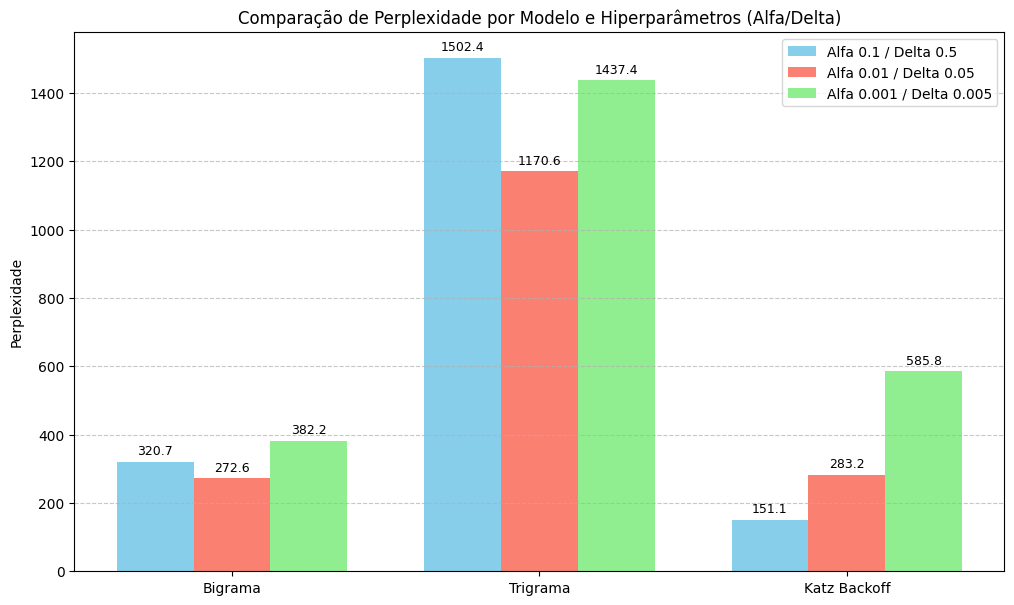

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Dados baseados nos seus experimentos
modelos = ['Bigrama', 'Trigrama', 'Katz Backoff']
alfas = ['Alfa 0.1 / Delta 0.5', 'Alfa 0.01 / Delta 0.05', 'Alfa 0.001 / Delta 0.005']

# Valores de perplexidade para cada cenário
# Katz Backoff usa Deltas: 0.5, 0.05, 0.005
v_0_1 = [320.69, 1502.44, 151.1]
v_0_01 = [272.63, 1170.61, 283.2]
v_0_001 = [382.19, 1437.38, 585.8]

x = np.arange(len(modelos))
largura = 0.25

plt.figure(figsize=(12, 7))

plt.bar(x - largura, v_0_1, largura, label='Alfa 0.1 / Delta 0.5', color='skyblue')
plt.bar(x, v_0_01, largura, label='Alfa 0.01 / Delta 0.05', color='salmon')
plt.bar(x + largura, v_0_001, largura, label='Alfa 0.001 / Delta 0.005', color='lightgreen')

plt.ylabel('Perplexidade')
plt.title('Comparação de Perplexidade por Modelo e Hiperparâmetros (Alfa/Delta)')
plt.xticks(x, modelos)
plt.legend()

# Adicionando rótulos de texto
def add_labels(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

for container in plt.gca().containers:
    add_labels(container)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Testes:
* ## **Etapas de pré-processamento**
O texto escolhido foi chestertor_brown.txt, está contido na base do Project Gutenberg
A normalização foi feita seguindo o enunciado do trabalho.
Todas as letras foram deixadas em minúsculas
Remoção de pontuação
Não houve tratamento de stopwords
O conjunto foi divido em teste e treino, seguindo hold out: 80% treino e 20% teste

* ## **Tipo de modelo de linguagem adotado**
* Foram utilizados três modelos:
  * Um baseado em bigrama
  * Um baseado em trigrama
  * E por último um baseado em Katz Backoff

* ## **Método de suavização utilizado**
  * O método de suavização utilizado foi a, suavização de Lidstone
  * Suavização de Laplace -> Evita a probabilidade nula(Pode ter um desempenho não muito bom).
  * Suavização de Lidstone -> Uma evolução da suaviação de Laplace, ao inves de somar 1, soma-se um número bem pequeno, não comprometendo tanto.
  * Good-Turing Discounting -> A probabilidade de eu ver algo que nunca vi (contagem 0) é igual à probabilidade das coisas que eu vi exatamente 1 vez. Pode ser complexo implementar, utiliza regressão linear
  * Kneser-Ney Smoothing -> Probabilidade de continuação, ela entende o contexto. Pensei em escolher essa, mas pelo que vi poderia se tornar bem complexo
  * Katz Backoff -> Se você não tem um Trigrama (A B C), dê um passo para trás e olhe o Bigrama (B C). Se não tiver o Bigrama, olhe o Unigrama (C).

* ## **Estratégia para tratamento de OOV**
  * Para o tratamento de OOV, o algoritmo faz a substituição de uma palavra desconhecida pelo token UNK
* ## **Valor de perplexidade obtido**
  * Os valores de perplexidade estão descritos no gráifoc junto com os modelos e seus resultados.
* ## **Exemplos de entrada e saída**

Abaixo segue os exemplos de testes e as palavras previstas por cada modelo


### Comparativo de Predições por Modelo (Top 2 sugestões + Probabilidades)

| Categoria | Frase de Entrada | Bigrama (Alfa 0.1) | Trigrama (Alfa 0.1) | Katz Backoff (Delta 0.5) |
| :--- | :--- | :--- | :--- | :--- |
| **Personagens** | father brown | 1. was (0.029) / 2. with (0.018) | 1. was (0.027) / 2. had (0.017) | 1. was (0.067) / 2. with (0.042) |
| | the little priest | 1. with (0.014) / 2. was (0.012) | 1. with (0.006) / 2. who (0.006) | 1. with (0.054) / 2. was (0.045) |
| | aristide valentin | 1. and (0.086) / 2. of (0.070) | 1. and (0.045) / 2. of (0.043) | 1. and (0.085) / 2. of (0.069) |
| | the tall flambeau | 1. and (0.025) / 2. s (0.016) | 1. youth (0.000) / 2. yours (0.000) | 1. and (0.095) / 2. s (0.060) |
| | flambeau said | 1. the (0.106) / 2. father (0.068) | 1. he (0.003) / 2. youth (0.000) | 1. the (0.215) / 2. father (0.138) |
| **Gramática** | in the middle of | 1. the (0.237) / 2. a (0.068) | 1. the (0.009) / 2. it (0.003) | 1. the (0.284) / 2. a (0.081) |
| | he looked at the | 1. <UNK> (0.094) / 2. other (0.022) | 1. same (0.024) / 2. <UNK> (0.022) | 1. <UNK> (0.102) / 2. other (0.024) |
| | there was a | 1. <UNK> (0.119) / 2. man (0.028) | 1. <UNK> (0.016) / 2. man (0.012) | 1. <UNK> (0.143) / 2. man (0.034) |
| | it was a very | 1. <UNK> (0.031) / 2. well (0.017) | 1. long (0.008) / 2. short (0.006) | 1. <UNK> (0.103) / 2. well (0.055) |
| **Mistério** | the dead body | 1. was (0.003) / 2. thrown (0.003) | 1. youth (0.000) / 2. yours (0.000) | 1. of (0.083) / 2. <UNK> (0.083) |
| | a drop of blood | 1. on (0.009) / 2. will (0.006) | 1. at (0.003) / 2. and (0.003) | 1. on (0.115) / 2. will (0.077) |
| | the murder was | 1. a (0.078) / 2. the (0.045) | 1. youth (0.000) / 2. yours (0.000) | 1. a (0.106) / 2. the (0.062) |
| | in the dark | 1. and (0.016) / 2. haired (0.008) | 1. trees (0.006) / 2. and (0.006) | 1. and (0.128) / 2. <UNK> (0.064) |
| | the police station | 1. three (0.003) / 2. of (0.003) | 1. youth (0.000) / 2. yours (0.000) | 1. three (0.498) / 2. of (0.498) |
| **Estresse (OOV)** | the internet connection | 1. and (0.086) / 2. of (0.070) | 1. and (0.045) / 2. of (0.043) | 1. and (0.085) / 2. of (0.069) |
| | used a smartphone | 1. and (0.086) / 2. of (0.070) | 1. of (0.037) / 2. and (0.037) | 1. and (0.085) / 2. of (0.069) |
| | a digital computer | 1. and (0.086) / 2. of (0.070) | 1. and (0.045) / 2. of (0.043) | 1. and (0.085) / 2. of (0.069) |
| | the brave astronaut | 1. and (0.086) / 2. of (0.070) | 1. and (0.045) / 2. of (0.043) | 1. and (0.085) / 2. of (0.069) |